# Wind history

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
from matplotlib.patches import Patch
from rioxarray.exceptions import NoDataInBounds
from tqdm.auto import tqdm
from matplotlib.ticker import EngFormatter
from dask.diagnostics import ProgressBar

from src.datasources import codab, chirps_gefs
from src.constants import *

All imports successful!


In [3]:
adm0 = codab.load_codab_from_blob(admin_level=0)

In [4]:
adm1 = codab.load_codab_from_blob(admin_level=1)

In [5]:
adm2 = codab.load_codab_from_blob(admin_level=2)

<Axes: >

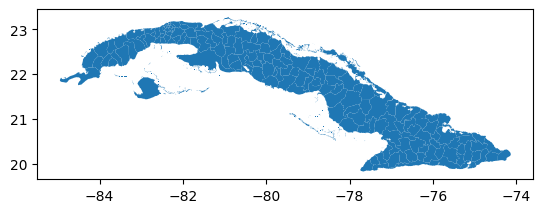

In [6]:
adm2.plot()

In [7]:
blob_name = "ghsl/pop/GHS_POP_E2025_GLOBE_R2023A_4326_3ss_V1_0.tif"
da_global = stratus.open_blob_cog(blob_name, container_name="raster").squeeze(
    drop=True
)

In [8]:
# clip to box (need to do this first, otherwise Python crashes on normal .rio.clip)
minx, miny, maxx, maxy = adm0.total_bounds
da_clip_box = da_global.rio.clip_box(
    minx=minx, miny=miny, maxx=maxx, maxy=maxy
)

In [9]:
da_ghsl = da_clip_box.rio.clip(adm0.geometry)

In [10]:
da_ghsl.attrs["_FillValue"] = np.nan

In [11]:
da_ghsl = da_ghsl.where(da_ghsl >= 0)

In [12]:
da_ghsl = da_ghsl.compute()

In [13]:
blob_name = (
    f"{PROJECT_PREFIX}/raw/noaa/nhc/wind_history/al132025_best_track.zip"
)
gdf_wind = stratus.load_shp_from_blob(
    blob_name, shapefile="AL132025_windswath.shp"
)

In [14]:
adm2_exp = adm2[adm2.intersects(gdf_wind.dissolve().iloc[0].geometry)]

In [15]:
adm1_pcodes = adm2_exp["ADM1_PCODE"].unique()

In [16]:
adm2_aoi = adm2[adm2["ADM1_PCODE"].isin(adm1_pcodes)]

In [17]:
adm1_aoi = adm1[adm1["ADM1_PCODE"].isin(adm1_pcodes)]

In [18]:
da_ghsl_aoi = da_ghsl.rio.clip(adm1_aoi.geometry)

In [19]:
gdf_wind["Wind Speed (knots)"] = (
    gdf_wind["RADII"].astype(int).astype("category")
)

In [20]:
minx, miny, maxx, maxy = adm1_aoi.total_bounds

In [22]:
issued_date = datetime(2025, 10, 29).date()

das = []
for lt in tqdm(range(16)):
    valid_date = issued_date + pd.Timedelta(days=lt)
    da_in = chirps_gefs.open_chirps_gefs(issued_date, valid_date)
    da_in["valid_date"] = valid_date
    das.append(da_in)

da_gefs = xr.concat(das, dim="valid_date").squeeze(drop=True)

  0%|          | 0/16 [00:00<?, ?it/s]

In [23]:
total_bounds = adm0.total_bounds

In [24]:
da_gefs_clip_box = da_gefs.rio.clip_box(*total_bounds)

In [25]:
with ProgressBar():
    da_gefs_clip_box_computed = da_gefs_clip_box.compute()

[################                        ] | 42% Completed | 117.15 s


KeyboardInterrupt: 

In [151]:
da_gefs_clip_box_computed.rio.clip(adm0.geometry).mean(dim=["x", "y"])

<xarray.DataArray (valid_date: 16)> Size: 64B
array([58.913578 ,  2.6574275,  2.7997465,  5.5100126,  6.322527 ,
        5.283186 ,  3.3758383,  3.5736706,  3.9866514,  5.5547953,
        5.533776 ,  6.691122 ,  5.0104117,  4.8547826,  3.8567379,
        2.8757498], dtype=float32)
Coordinates:
  * valid_date   (valid_date) object 128B 2025-10-29 2025-10-30 ... 2025-11-13
    spatial_ref  int64 8B 0

In [173]:
gefs_dates = pd.date_range("2025-10-29", "2025-10-29")

In [199]:
# get IMERG
query = """
SELECT *
FROM public.imerg
WHERE pcode = 'CU'
"""
with stratus.get_engine(stage="prod").connect() as con:
    df_imerg = pd.read_sql(query, con)

In [200]:
df_imerg["valid_date"] = pd.to_datetime(df_imerg["valid_date"])
df_imerg = df_imerg.sort_values("valid_date")

In [202]:
df_imerg.iloc[-20:]

,iso3,pcode,valid_date,adm_level,mean,median,min,max,count,sum,std
8360,CUB,CU,2025-10-11,0,25.584150,20.485,0.0,105.115005,3791,96989.5160,22.715750
8361,CUB,CU,2025-10-12,0,24.592865,22.535,0.0,101.960010,3791,93231.5500,22.194786
8693,CUB,CU,2025-10-13,0,28.438843,14.430,0.0,159.315020,3791,107811.6600,33.003128
8694,CUB,CU,2025-10-14,0,5.800051,1.950,0.0,72.045000,3791,21987.9940,9.121056
8695,CUB,CU,2025-10-15,0,8.314076,5.290,0.0,56.960000,3791,31518.6640,8.727547
8696,CUB,CU,2025-10-16,0,3.369298,0.000,0.0,66.615000,3791,12773.0100,8.744963
8697,CUB,CU,2025-10-17,0,0.143285,0.000,0.0,11.419999,3791,543.1950,0.750619
8698,CUB,CU,2025-10-18,0,0.706292,0.000,0.0,22.960000,3791,2677.5550,2.303868
8699,CUB,CU,2025-10-19,0,5.397804,2.190,0.0,117.800000,3791,20463.0740,9.210676
8362,CUB,CU,2025-10-20,0,6.787998,3.130,0.0,96.700000,3791,25733.2990,9.527491


<Axes: xlabel='valid_date'>

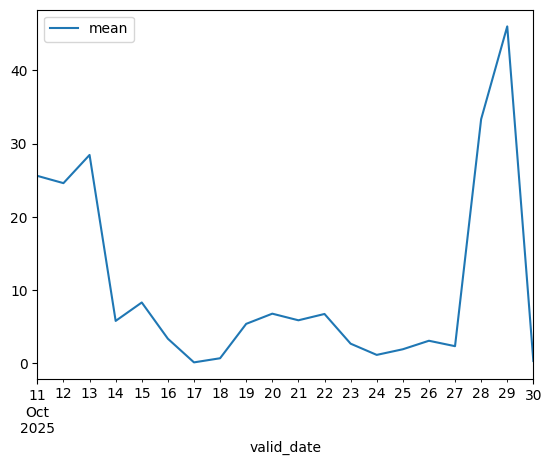

In [207]:
df_imerg.iloc[-20:].plot(x="valid_date", y="mean")

In [32]:
imerg_dates = df_imerg.iloc[-2:]["valid_date"].dt.date

In [33]:
imerg_dates

8535    2025-10-28
8536    2025-10-29
Name: valid_date, dtype: object

In [28]:
IMERG_BLOB_NAME = (
    "imerg/daily/late/v7/processed/imerg-daily-late-{date_str}.tif"
)

In [34]:
das = []
for d in imerg_dates:
    blob_name = IMERG_BLOB_NAME.format(date_str=d)
    da_in = stratus.open_blob_cog(
        blob_name, stage="prod", container_name="raster"
    )
    da_in["date"] = d
    das.append(da_in)

In [35]:
da_imerg = xr.concat(das, dim="date").squeeze(drop=True)

In [156]:
da_imerg_clip_box = da_imerg.rio.clip_box(*total_bounds)

In [157]:
with ProgressBar():
    da_imerg_clip_box_computed = da_imerg_clip_box.compute()

[########################################] | 100% Completed | 215.17 ms


In [158]:
da_imerg_clip = da_imerg_clip_box_computed.rio.clip(
    adm0.geometry, all_touched=True
)

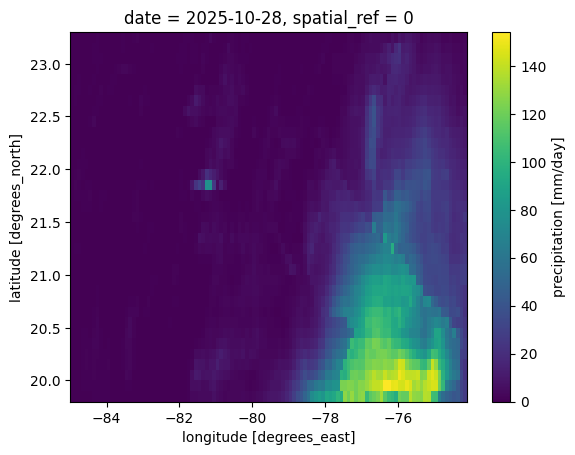

In [160]:
da_imerg_clip_box_computed.isel(date=0).plot()

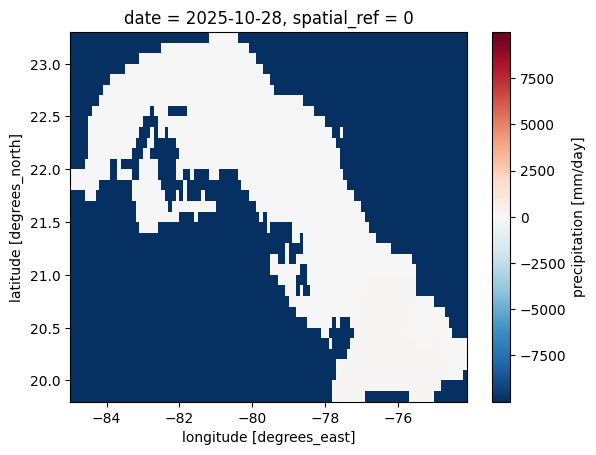

In [159]:
da_imerg_clip.isel(date=0).plot()

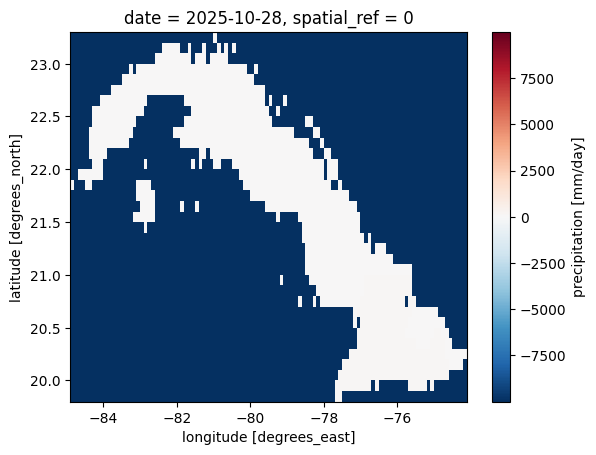

In [162]:
da_imerg_clip_box_computed.rio.clip(adm0.geometry, all_touched=False).isel(
    date=0
).plot()

In [164]:
# for CHIRPS-GEFS:
# da_rainfall = (
#     da_gefs_clip_box_computed.where(da_gefs_clip_box_computed > 0)
#     .rio.clip(adm0.geometry)
#     .sel(valid_date=gefs_dates)
# )

# for IMERG:
da_rainfall = da_imerg_clip.where(da_imerg_clip > 0).sum(dim="date")

(np.float64(-79.557084656),
 np.float64(-74.031187439),
 np.float64(19.725971602999998),
 np.float64(22.025693512))

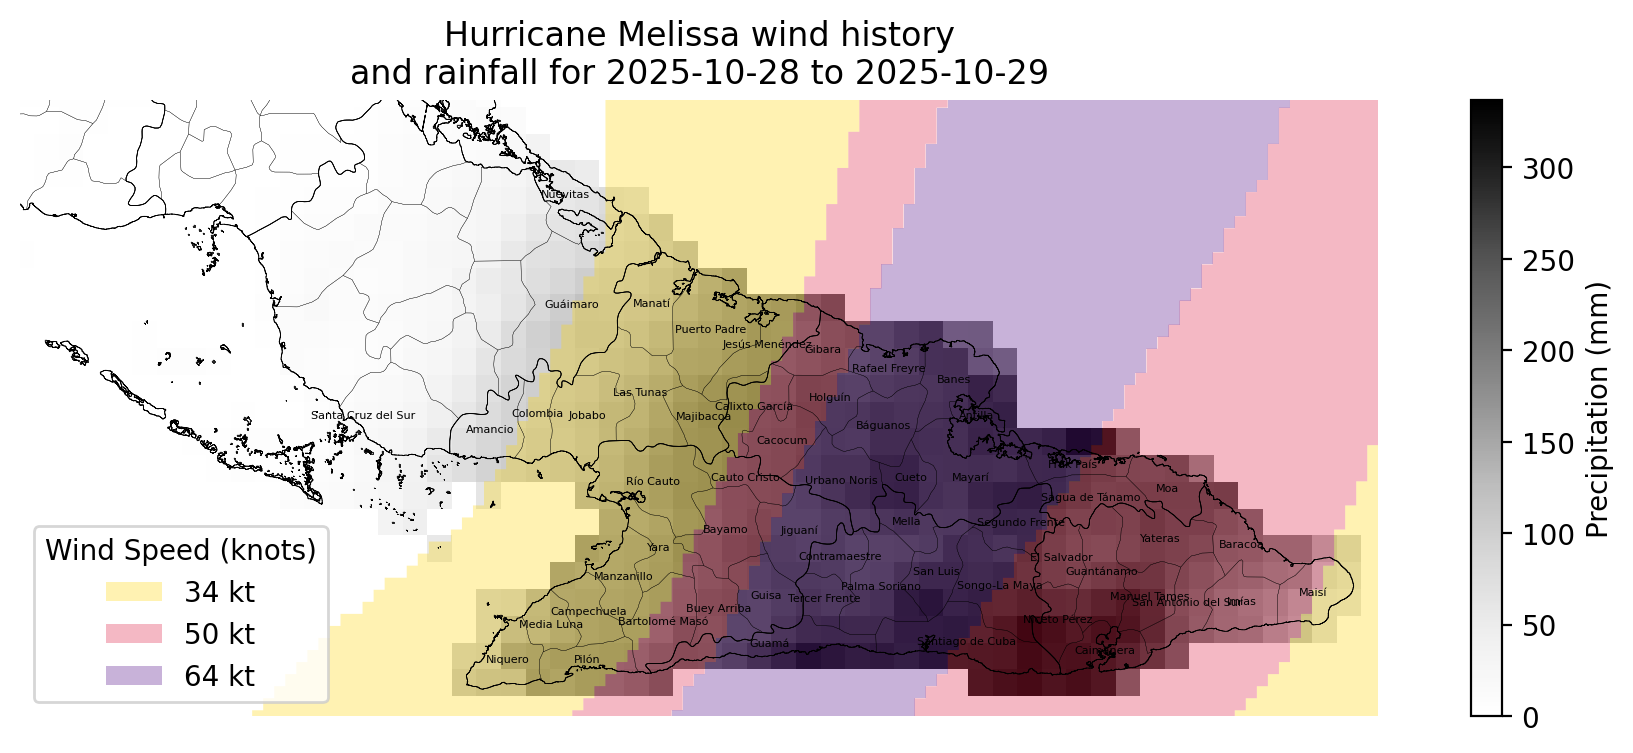

In [188]:
fig, ax = plt.subplots(dpi=200, figsize=(12, 4))

minx, miny, maxx, maxy = adm2_exp.total_bounds

adm1.boundary.plot(ax=ax, linewidth=0.3, color="k")
adm2.boundary.plot(ax=ax, linewidth=0.1, color="k")

for _, row in adm2_exp.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["ADM2_ES"],
        (c.x, c.y),
        ha="center",
        va="center",
        fontsize=4,
    )

da_rainfall.where(da_rainfall >= 0).plot(
    ax=ax,
    cmap="Greys",
    cbar_kwargs={"label": "Precipitation (mm)"},
    vmin=0,
)

alpha = 0.3
color_map = {34: "gold", 50: "crimson", 64: "indigo"}
for value, color in color_map.items():
    gdf_wind[gdf_wind["Wind Speed (knots)"] == value].plot(
        ax=ax, color=color, alpha=alpha, label=f"{value} kt"
    )

handles = [
    Patch(facecolor=color, label=f"{value} kt", alpha=alpha)
    for value, color in color_map.items()
]

ax.legend(
    handles=handles, title="Wind Speed (knots)", loc="lower left", frameon=True
)

ax.set_title(
    "Hurricane Melissa wind history\n"
    f"and rainfall for {imerg_dates.min()} to {imerg_dates.max()}"
)

# da_ghsl_aoi.plot(ax=ax, vmax=5, cmap="Greys")
margin = 0.1
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
ax.axis("off")

In [166]:
levels = [25, 50, 100, 150, 200, 300, 400, 500, 750]
colors = [
    "lawngreen",
    "limegreen",
    "yellow",
    "gold",
    "darkorange",
    "red",
    "firebrick",
    "magenta",
    "darkmagenta",
]
cbar_kwargs = {
    "label": "Precipitation (mm)",  # Set label for the colorbar
    "shrink": 0.8,  # Shrink the colorbar to 80% of its default size
}

In [167]:
gdf_wind

,RADII,STORMID,BASIN,STORMNUM,ADVNUM,STARTDTG,ENDDTG,geometry,Wind Speed (knots)
0,64.0,AL132025,al,13.0,38,2025102106,2025103018,"POLYGON ((-77.89393 16.01296, -77.89393 16.057...",64
1,50.0,AL132025,al,13.0,38,2025102106,2025103018,"POLYGON ((-74.25577 15.33807, -74.25577 15.383...",50
2,34.0,AL132025,al,13.0,38,2025102106,2025103018,"POLYGON ((-73.08796 12.95348, -73.08796 12.998...",34


(np.float64(-79.557084656),
 np.float64(-74.031187439),
 np.float64(19.725971602999998),
 np.float64(22.025693512))

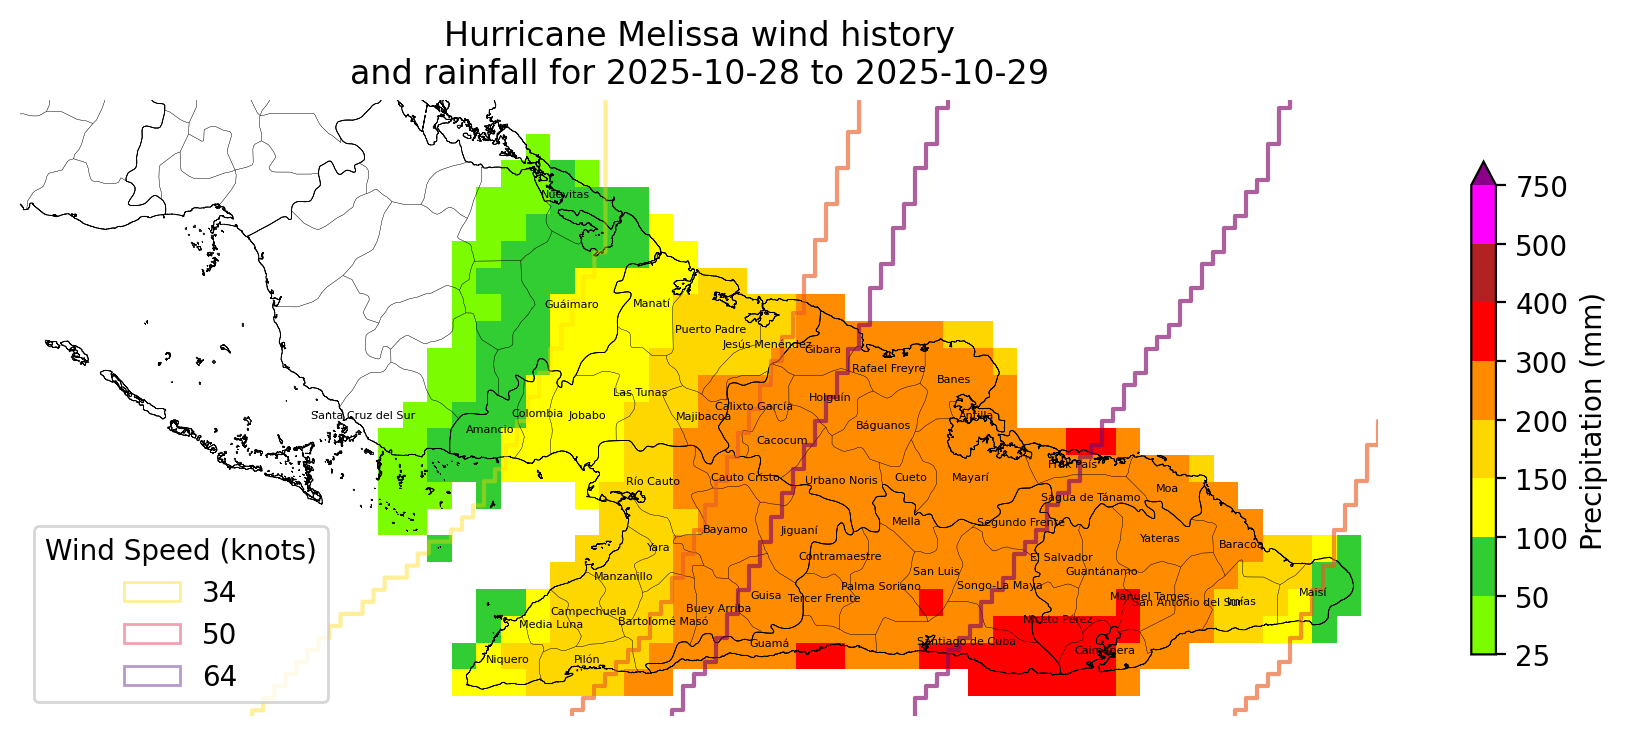

In [187]:
fig, ax = plt.subplots(dpi=200, figsize=(12, 4))

minx, miny, maxx, maxy = adm2_exp.total_bounds

adm1.boundary.plot(ax=ax, linewidth=0.3, color="k")
adm2.boundary.plot(ax=ax, linewidth=0.1, color="k")

for _, row in adm2_exp.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["ADM2_ES"],
        (c.x, c.y),
        ha="center",
        va="center",
        fontsize=4,
    )

da_rainfall.plot(
    ax=ax, levels=levels, colors=colors, extend="max", cbar_kwargs=cbar_kwargs
)

alpha = 0.4
for wind, color in color_map.items():
    gdf_wind[gdf_wind["RADII"] == wind].boundary.plot(
        ax=ax, color=color, alpha=alpha
    )

# Create legend using the same color map
legend_elements = [
    Patch(facecolor="white", edgecolor=color, label=f"{wind}", alpha=alpha)
    for wind, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Wind Speed (knots)",
    loc="lower left",
    frameon=True,
)

ax.legend(
    handles=legend_elements, title="Wind Speed (knots)", loc="lower left"
)

ax.set_title(
    "Hurricane Melissa wind history\n"
    f"and rainfall for {imerg_dates.min()} to {imerg_dates.max()}"
)

# da_ghsl_aoi.plot(ax=ax, vmax=5, cmap="Greys")
margin = 0.1
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
ax.axis("off")

In [58]:
dicts = []
for pcode, group in tqdm(adm2.groupby("ADM2_PCODE")):
    ghsl_adm2 = da_ghsl.rio.clip(group.geometry)
    dicts.append({"ADM2_PCODE": pcode, "total_pop": int(ghsl_adm2.sum())})

  0%|          | 0/168 [00:00<?, ?it/s]

In [59]:
df_adm2_pop = pd.DataFrame(dicts)

In [91]:
df_adm2_pop_aoi = df_adm2_pop[
    df_adm2_pop["ADM2_PCODE"].isin(adm2_aoi["ADM2_PCODE"].unique())
]

In [125]:
HOLGUIN2 = "CU0709"

In [150]:
dicts = []
for pcode, group in tqdm(adm2_exp.groupby("ADM2_PCODE")):
    ghsl_adm2 = da_ghsl.rio.clip(group.geometry)
    for speed, row in gdf_wind.set_index("RADII").iterrows():
        try:
            ghsl_adm2_speed = ghsl_adm2.rio.clip([row.geometry])
            pop_exp = int(ghsl_adm2_speed.sum())
        except NoDataInBounds:
            pop_exp = 0
        dicts.append(
            {"ADM2_PCODE": pcode, "speed": int(speed), "pop_exp": pop_exp}
        )

  0%|          | 0/57 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [62]:
df_adm2_exp_raw = pd.DataFrame(dicts)

In [131]:
df_adm2_exp = df_adm2_exp_raw.pivot(
    index="ADM2_PCODE", columns="speed", values="pop_exp"
)

df_adm2_exp = df_adm2_exp.rename(
    columns={x: f"exp_{x}_knots" for x in df_adm2_exp.columns}
)

In [132]:
df_adm2_exp = df_adm2_exp.reset_index().merge(df_adm2_pop_aoi, how="right")

In [133]:
df_adm2_exp["exp_34_knots"] = df_adm2_exp[
    ["exp_34_knots", "exp_50_knots", "exp_64_knots"]
].sum(axis=1)
df_adm2_exp["exp_50_knots"] = df_adm2_exp[
    ["exp_50_knots", "exp_64_knots"]
].sum(axis=1)

In [134]:
df_adm2_exp = df_adm2_exp.fillna(0)
df_adm2_exp = df_adm2_exp.set_index("ADM2_PCODE")
df_adm2_exp = df_adm2_exp.astype(int).reset_index()

In [135]:
df_adm2_exp

,ADM2_PCODE,exp_34_knots,exp_50_knots,exp_64_knots,total_pop
0,CU0201,0,0,0,336330
1,CU0202,0,0,0,23048
2,CU0203,0,0,0,28990
3,CU0204,0,0,0,68483
4,CU0205,19803,0,0,33377
...,...,...,...,...,...
62,CU1505,77882,77882,77882,77882
63,CU1506,524979,524979,518426,524979
64,CU1507,38865,38865,38288,38866
65,CU1508,92451,92451,77062,92452


In [136]:
df_out = adm2[["ADM1_PCODE", "ADM1_ES", "ADM2_PCODE", "ADM2_ES"]].merge(
    df_adm2_exp
)

save_path = "temp/cub_melissa_adm2_wind_exposure.csv"
df_out.to_csv(save_path, index=False, encoding="utf-8-sig")

save_path = "temp/cub_melissa_adm2_wind_exposure.xlsx"
df_out.to_excel(save_path, index=False)

In [168]:
da_rainfall_interp = da_rainfall.interp_like(
    da_ghsl_aoi, method="nearest", kwargs={"fill_value": "extrapolate"}
).squeeze(drop=True)

In [169]:
rain_threshs = [100, 200, 300, 400, 500]

In [170]:
dicts = []
for pcode, group in tqdm(adm2_exp.groupby("ADM2_PCODE")):
    ghsl_adm2 = da_ghsl.rio.clip(group.geometry)
    for rain_thresh in rain_threshs:
        da_ghsl_rain_thresh = ghsl_adm2.where(
            da_rainfall_interp >= rain_thresh
        )
        dicts.append(
            {
                "ADM2_PCODE": pcode,
                "rain_thresh": rain_thresh,
                "pop_exp": int(da_ghsl_rain_thresh.sum()),
            }
        )

  0%|          | 0/57 [00:00<?, ?it/s]

In [171]:
df_adm2_exp_rain_raw = pd.DataFrame(dicts)

In [172]:
df_adm2_exp_rain = df_adm2_exp_rain_raw.pivot(
    index="ADM2_PCODE", columns="rain_thresh", values="pop_exp"
)

df_adm2_exp_rain = df_adm2_exp_rain.rename(
    columns={x: f"exp_{x}_mm" for x in df_adm2_exp_rain.columns}
)

df_adm2_exp_rain = df_adm2_exp_rain.reset_index().merge(
    df_adm2_pop_aoi, how="right"
)

In [173]:
df_adm2_exp_rain = df_adm2_exp_rain.fillna(0)
df_adm2_exp_rain = df_adm2_exp_rain.set_index("ADM2_PCODE")
df_adm2_exp_rain = df_adm2_exp_rain.astype(int).reset_index()

In [174]:
df_exp = df_adm2_exp.merge(df_adm2_exp_rain)

In [175]:
df_exp

,ADM2_PCODE,exp_34_knots,exp_50_knots,exp_64_knots,total_pop,exp_100_mm,exp_200_mm,exp_300_mm,exp_400_mm,exp_500_mm
0,CU0201,0,0,0,336330,0,0,0,0,0
1,CU0202,0,0,0,23048,0,0,0,0,0
2,CU0203,0,0,0,28990,0,0,0,0,0
3,CU0204,0,0,0,68483,0,0,0,0,0
4,CU0205,19803,0,0,33377,12311,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
62,CU1505,77882,77882,77882,77882,77882,77882,52720,0,0
63,CU1506,524979,524979,518426,524979,524979,524979,20986,0,0
64,CU1507,38865,38865,38288,38866,38866,38866,0,0,0
65,CU1508,92451,92451,77062,92452,92452,92452,3884,0,0


In [189]:
df_out = adm2[["ADM1_PCODE", "ADM1_ES", "ADM2_PCODE", "ADM2_ES"]].merge(df_exp)

df_out = df_out[
    [x for x in df_out.columns if x != "total_pop"] + ["total_pop"]
]

save_path = "temp/cub_melissa_adm2_wind_rain_exposure.csv"
df_out.to_csv(save_path, index=False, encoding="utf-8-sig")

save_path = "temp/cub_melissa_adm2_wind_rain_exposure.xlsx"
df_out.to_excel(save_path, index=False)

In [177]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/cub_melissa_adm2_wind_rain_exposure.parquet"
)
stratus.upload_parquet_to_blob(df_out, blob_name)

<Axes: >

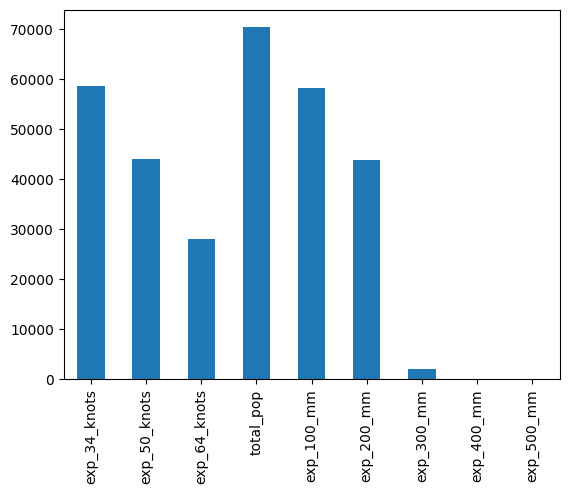

In [179]:
df_exp.mean(numeric_only=True).plot.bar()

In [190]:
df_plot = df_exp.merge(adm2)

In [191]:
def plot_exp(df_plot, xcol, ycol):
    fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    xmax = df_plot[xcol].max() * 1.1
    ymax = df_plot[ycol].max() * 1.1
    xymax = max(xmax, ymax)

    for _, row in df_plot.iterrows():
        ax.annotate(
            row["ADM2_ES"],
            row[[xcol, ycol]],
            va="center",
            ha="center",
            fontsize=6,
            rotation=-45,
        )

    ax.set_xlim((0, xymax))
    ax.set_ylim((0, xymax))

    ax.xaxis.set_major_formatter(EngFormatter(unit=""))
    ax.yaxis.set_major_formatter(EngFormatter(unit=""))

    [ax.spines[x].set_visible(False) for x in ["top", "right"]]
    return fig, ax

Text(0, 0.5, 'Population exposed to ≥ 100 mm rainfall')

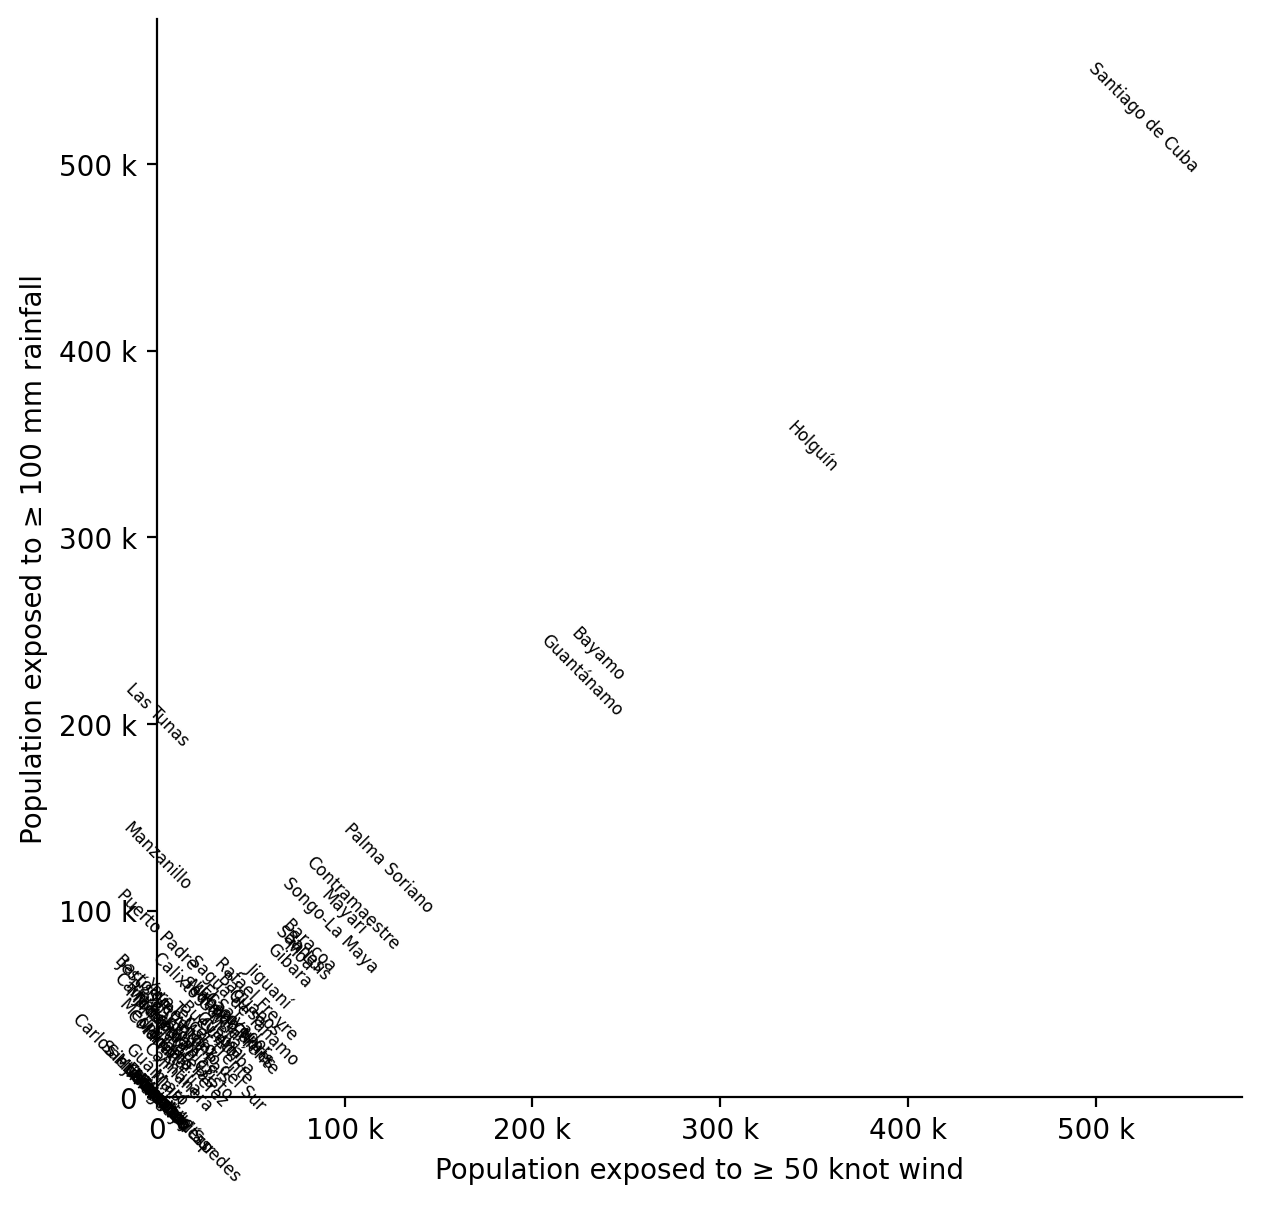

In [192]:
speed = 50
rain = 100

xcol, ycol = f"exp_{speed}_knots", f"exp_{rain}_mm"

fig, ax = plot_exp(df_plot, xcol, ycol)

ax.set_xlabel(f"Population exposed to ≥ {speed} knot wind")
ax.set_ylabel(f"Population exposed to ≥ {rain} mm rainfall")

In [193]:
df_plot["max_100_mm_50_knots"] = df_plot[["exp_100_mm", "exp_50_knots"]].max(
    axis=1
)
df_plot["min_100_mm_50_knots"] = df_plot[["exp_100_mm", "exp_50_knots"]].min(
    axis=1
)

df_plot["max_200_mm_64_knots"] = df_plot[["exp_200_mm", "exp_64_knots"]].max(
    axis=1
)
df_plot["min_200_mm_64_knots"] = df_plot[["exp_200_mm", "exp_64_knots"]].min(
    axis=1
)

[None, None]

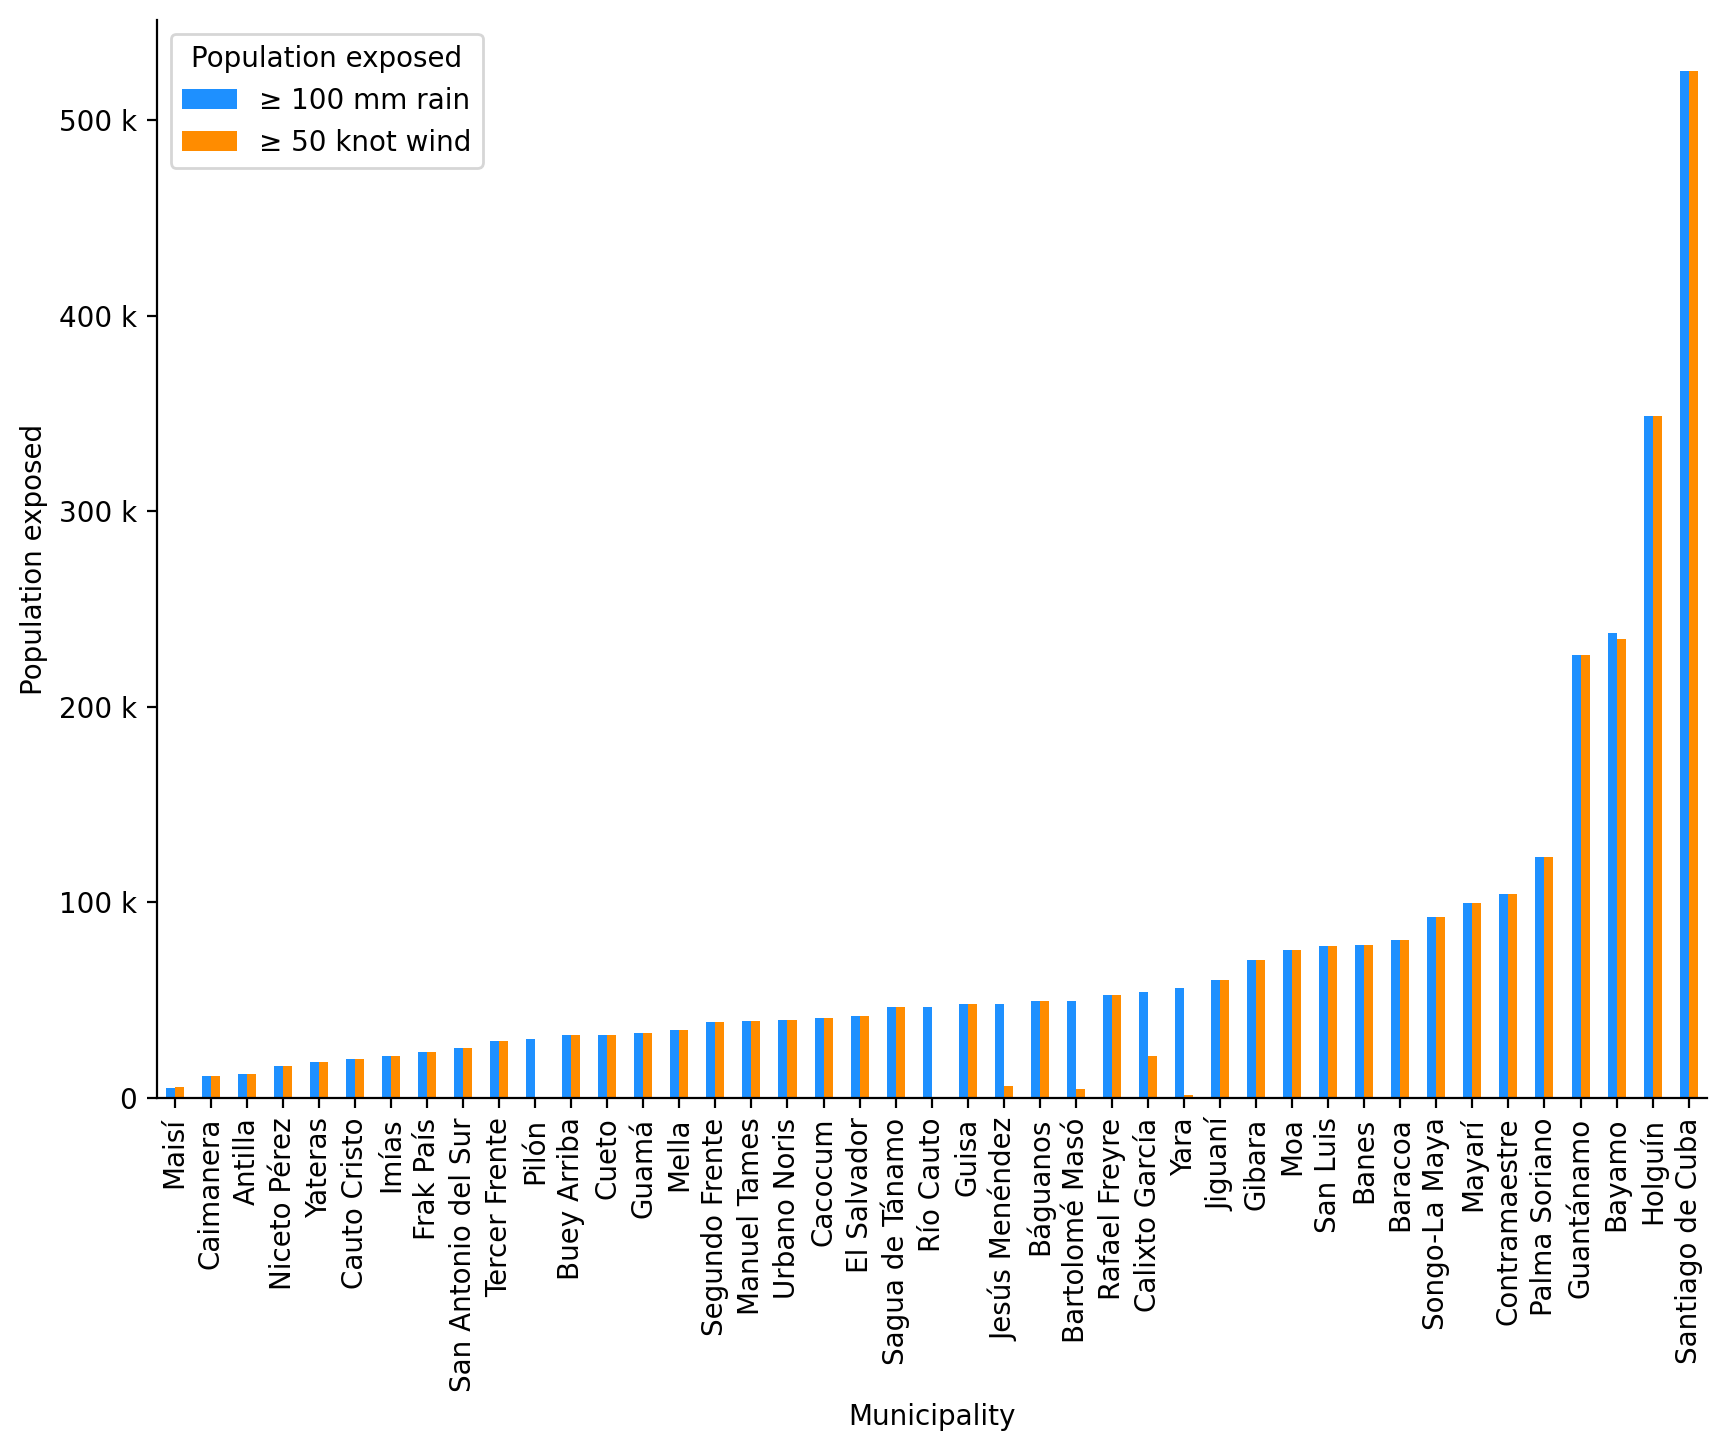

In [194]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
df_plot[df_plot["min_100_mm_50_knots"] > 0].sort_values(
    "max_100_mm_50_knots"
).plot.bar(
    x="ADM2_ES",
    y=["exp_100_mm", "exp_50_knots"],
    ax=ax,
    color=["dodgerblue", "darkorange"],
)

ax.legend(
    ["≥ 100 mm rain", "≥ 50 knot wind"],
    title="Population exposed",
)

ax.set_ylabel("Population exposed")
ax.set_xlabel("Municipality")
ax.yaxis.set_major_formatter(EngFormatter(unit=""))

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [198]:
df_exp[df_exp["ADM2_PCODE"] == "CU0502"]

,ADM2_PCODE,exp_34_knots,exp_50_knots,exp_64_knots,total_pop,exp_100_mm,exp_200_mm,exp_300_mm,exp_400_mm,exp_500_mm
14,CU0502,237719,234594,760,237719,237719,237719,0,0,0


[None, None]

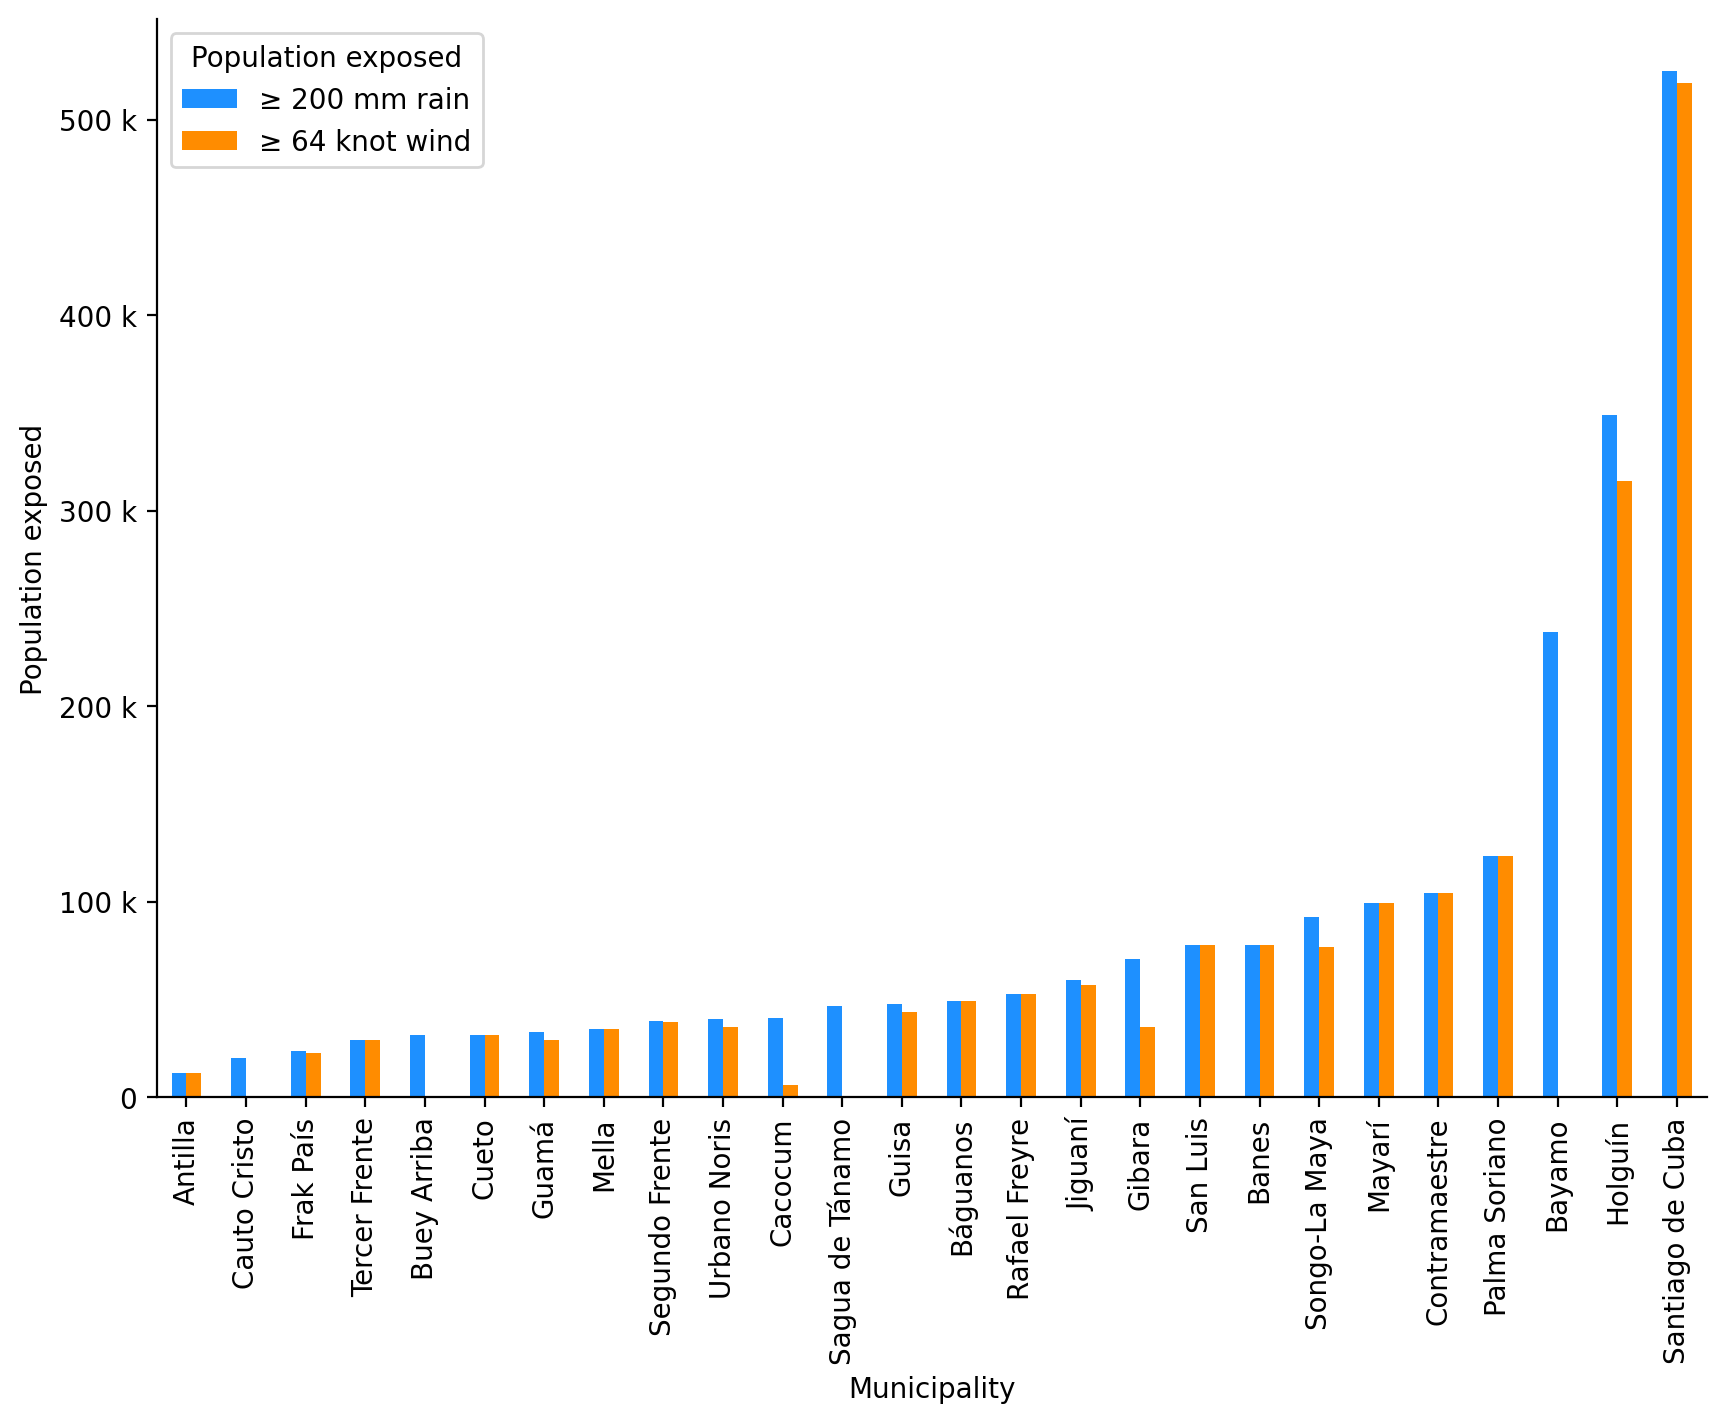

In [195]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
df_plot[df_plot["min_200_mm_64_knots"] > 0].sort_values(
    "max_200_mm_64_knots"
).plot.bar(
    x="ADM2_ES",
    y=["exp_200_mm", "exp_64_knots"],
    ax=ax,
    color=["dodgerblue", "darkorange"],
)

ax.legend(
    ["≥ 200 mm rain", "≥ 64 knot wind"],
    title="Population exposed",
)

ax.set_ylabel("Population exposed")
ax.set_xlabel("Municipality")

ax.yaxis.set_major_formatter(EngFormatter(unit=""))

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

Text(0, 0.5, 'Population exposed to ≥ 200 mm rainfall')

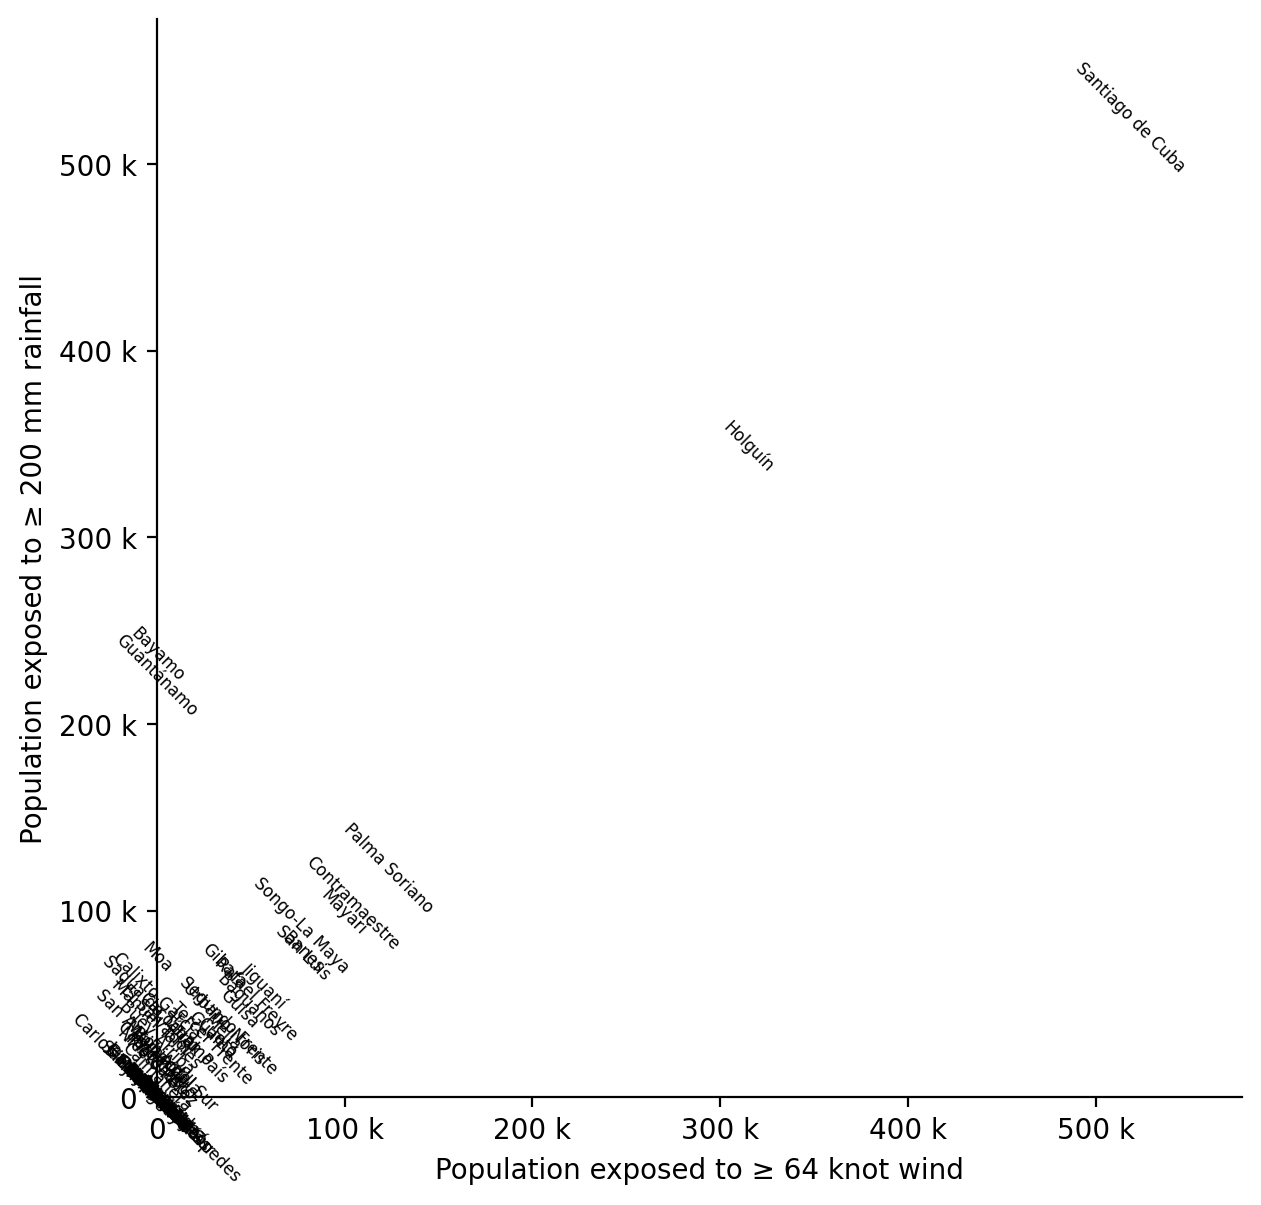

In [196]:
speed = 64
rain = 200

xcol, ycol = f"exp_{speed}_knots", f"exp_{rain}_mm"

fig, ax = plot_exp(df_plot, xcol, ycol)

ax.set_xlabel(f"Population exposed to ≥ {speed} knot wind")
ax.set_ylabel(f"Population exposed to ≥ {rain} mm rainfall")

In [369]:
for x in df_plot.columns:
    if "exp" in x and "frac" not in x:
        df_plot[f"frac_{x}"] = df_plot[x] / df_plot["total_pop"]

Text(0, 0.5, 'Fraction of population exposed to ≥ 200 mm rainfall')

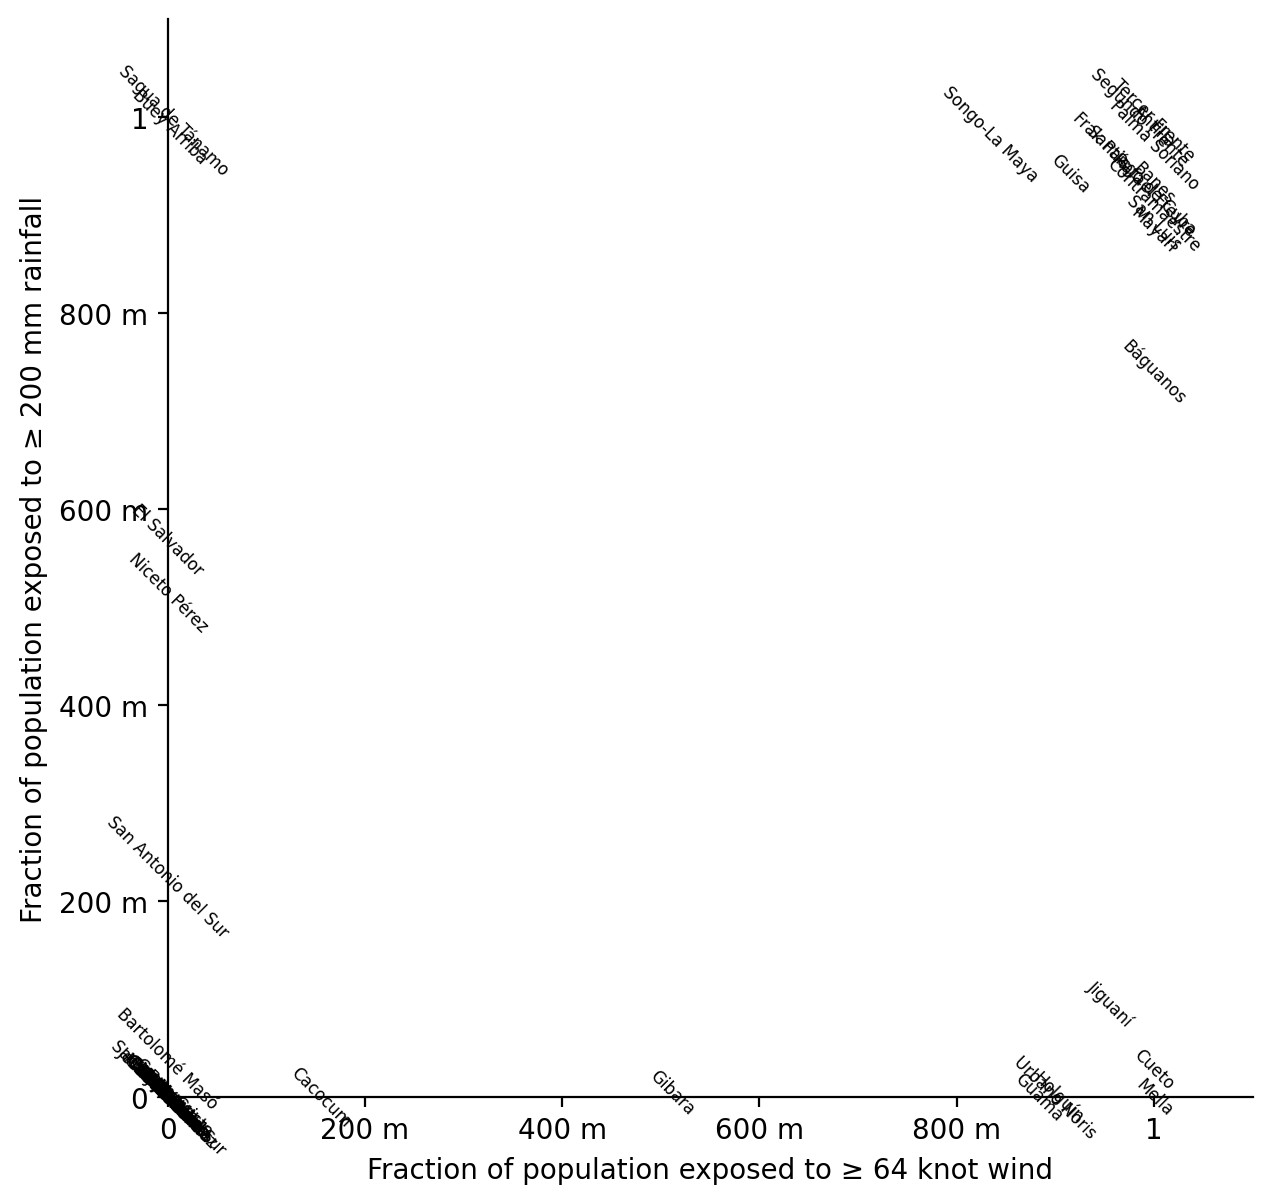

In [375]:
speed = 64
rain = 200

xcol, ycol = f"frac_exp_{speed}_knots", f"frac_exp_{rain}_mm"

fig, ax = plot_exp(df_plot, xcol, ycol)

ax.set_xlabel(f"Fraction of population exposed to ≥ {speed} knot wind")
ax.set_ylabel(f"Fraction of population exposed to ≥ {rain} mm rainfall")

In [295]:
da_rainfall_interp

<xarray.DataArray (y: 3065, x: 6391)> Size: 78MB
array([[9.125, 9.125, 9.125, ...,   nan,   nan,   nan],
       [9.125, 9.125, 9.125, ...,   nan,   nan,   nan],
       [9.125, 9.125, 9.125, ...,   nan,   nan,   nan],
       ...,
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan]],
      shape=(3065, 6391), dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 51kB -79.46 -79.46 -79.45 ... -74.13 -74.13 -74.13
  * y            (y) float64 25kB 22.38 22.38 22.38 22.38 ... 19.83 19.83 19.83
Attributes:
    TIFFTAG_DOCUMENTNAME:      /home/chc-data-out/products/EWX/data/forecasts...
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 9.0.0, NV5 Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:10:29 02:55:22
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    TIFFTAG_RESOLUTIONUNIT:    2 (pixels/inch)
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0

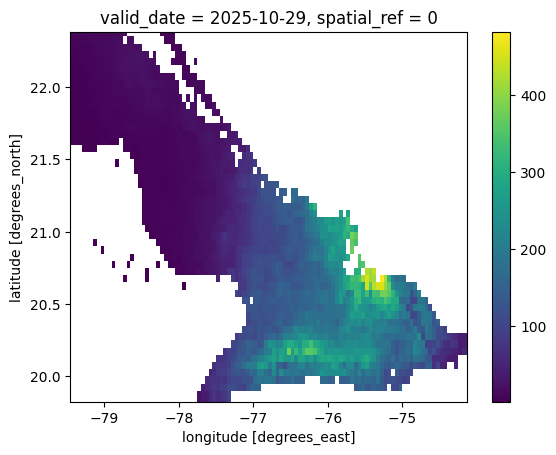

In [287]:
da_rainfall_interp.plot()